### **Experiments for N-dim convex optimization problem with noise**

In [2]:
import gymnasium as gym
import src.gymnasium_envs.convex_optimization_env
import src.utils.exps_utils as exps
import numpy as np
import pandas as pd

seed = 1337
max_iterations = 10000

env_id = "convex_optimization_env/ConvexOptimization-v1"

available_dims = [2, 5, 10, 100]

base_env_kwargs = {
    "add_noise" : True,
    "amplitude" : 5,
    "frequency" : 10
}

### 1. Convergence on No Noise vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

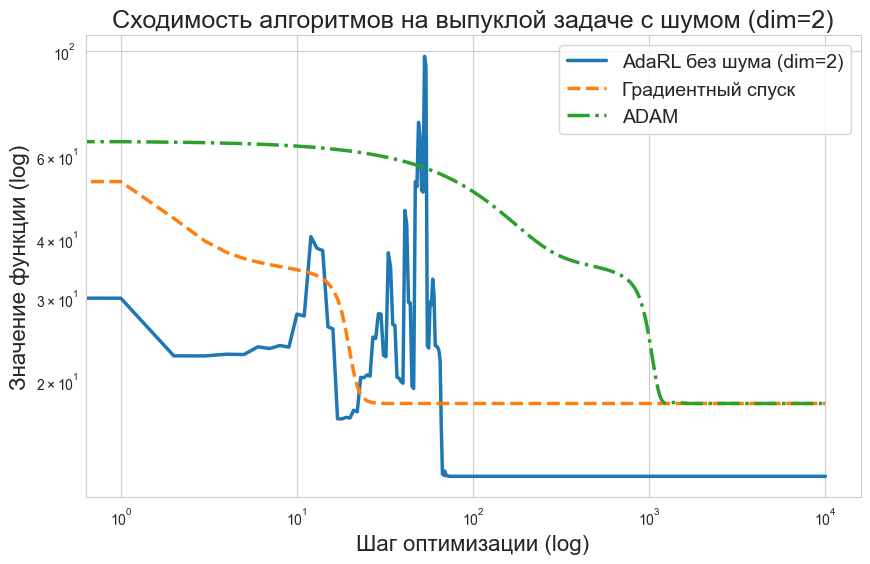

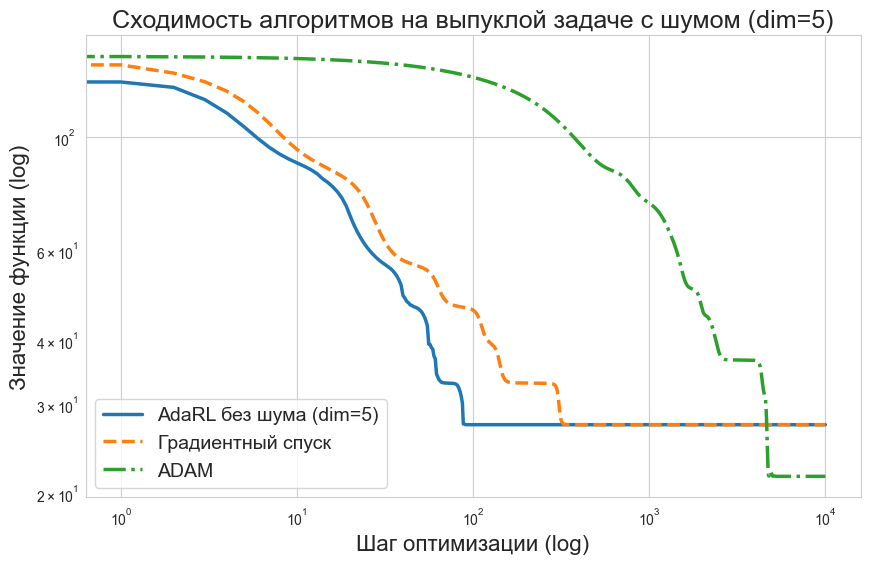

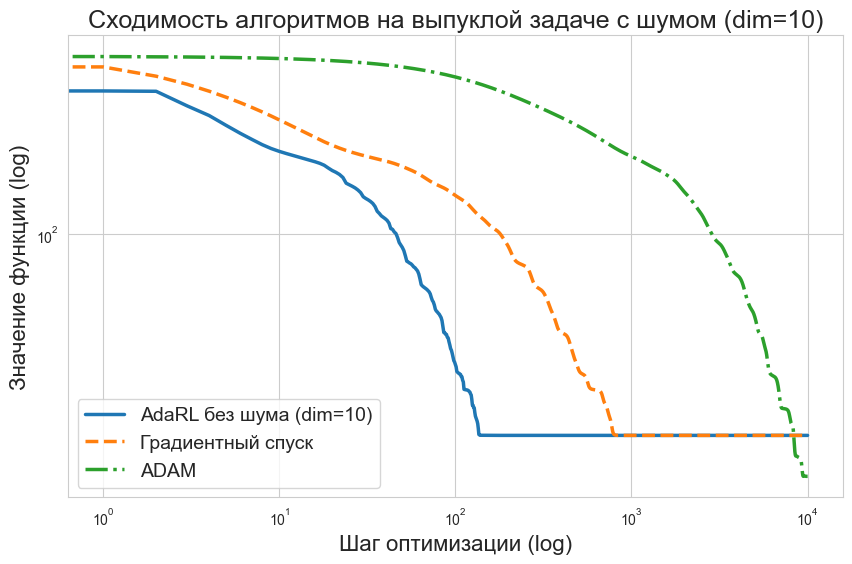

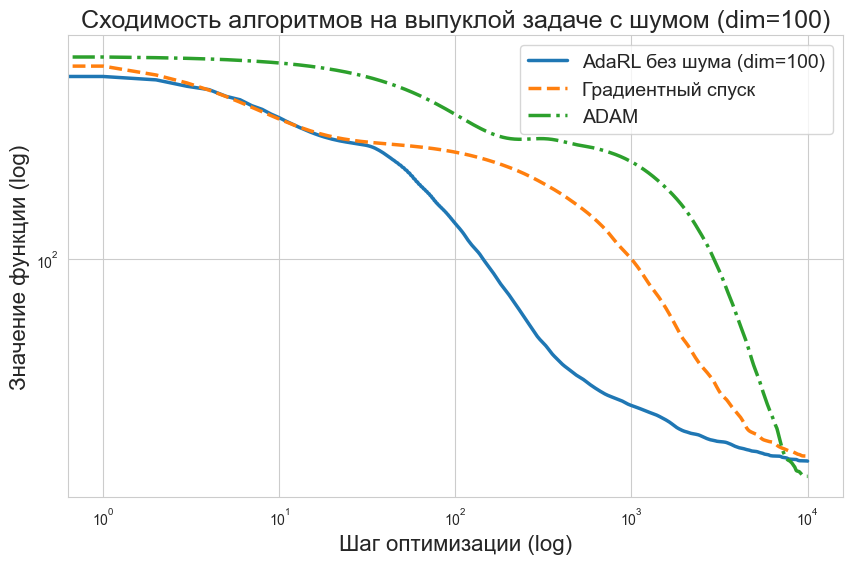

In [3]:
for dim in available_dims:
    stats = f"../models/{dim}d_convex_vec_normalize.pkl"
    model = f"../models/{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL без шума (dim={dim})", env_config=env_config, model_dir=model_dir)

    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config, add_noise=True)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config, add_noise=True)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов на выпуклой задаче с шумом (dim={dim})")
    

### 2. Convergence vs. ADAM and GD 

Let's build convergence graphs for models trained on a specific dimension

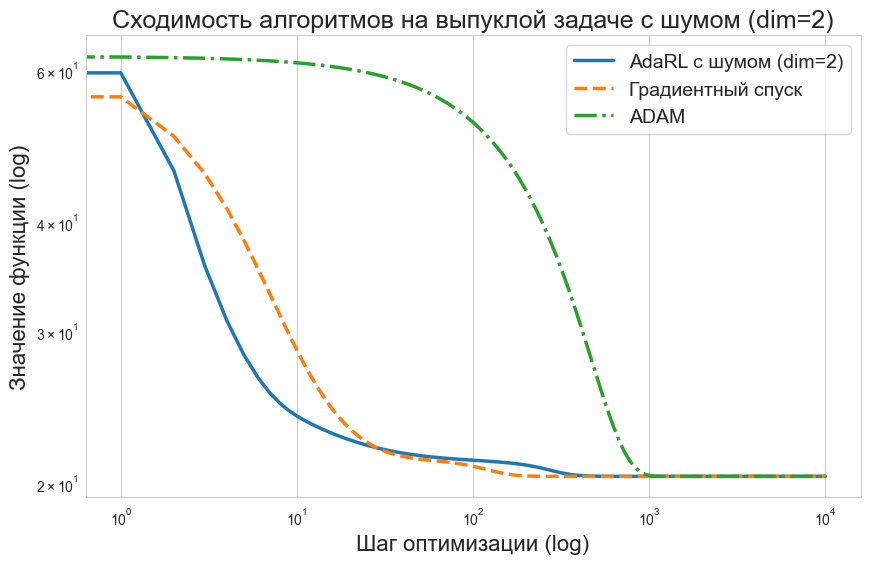

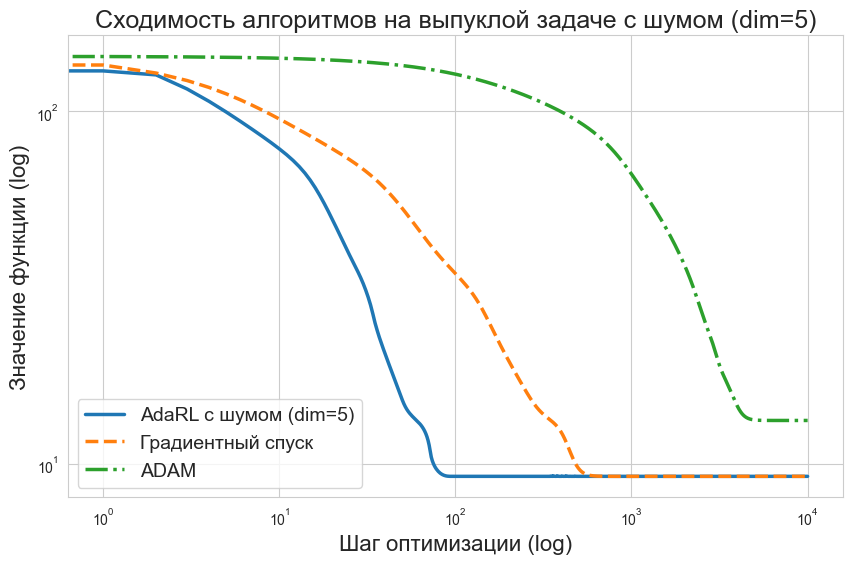

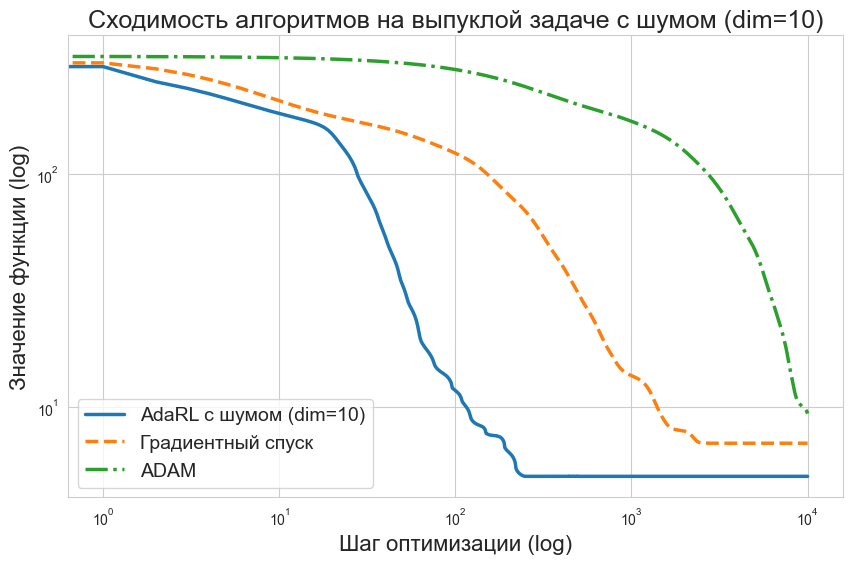

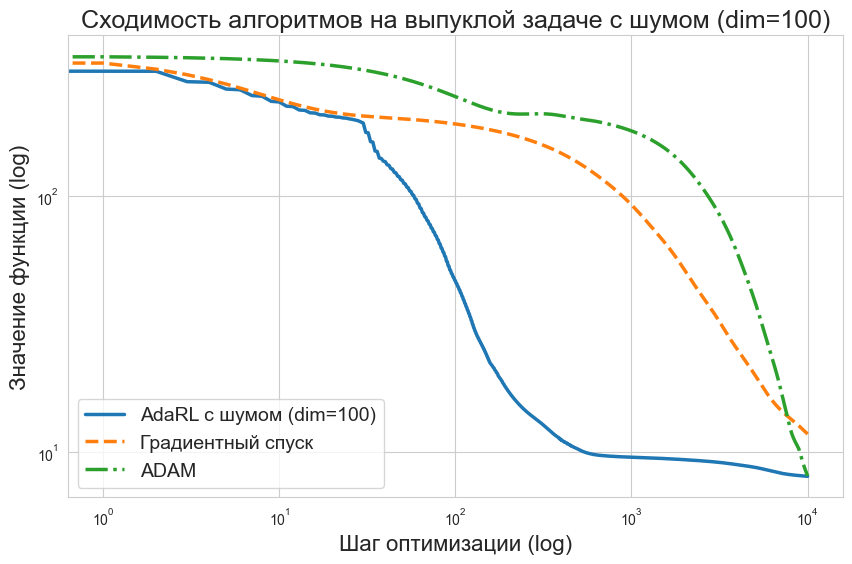

In [4]:
base_env_kwargs = {
    "add_noise" : True,
    "amplitude" : 2.5,
    "frequency" : 5
}

for dim in available_dims:
    stats = f"../models/noise_{dim}d_convex_vec_normalize.pkl"
    model = f"../models/noise_{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL с шумом (dim={dim})", env_config=env_config, model_dir=model_dir)

    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config, add_noise=True)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config, add_noise=True)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов на выпуклой задаче с шумом (dim={dim})")
    

### 3. Convergence of algorithms for different noise parameters

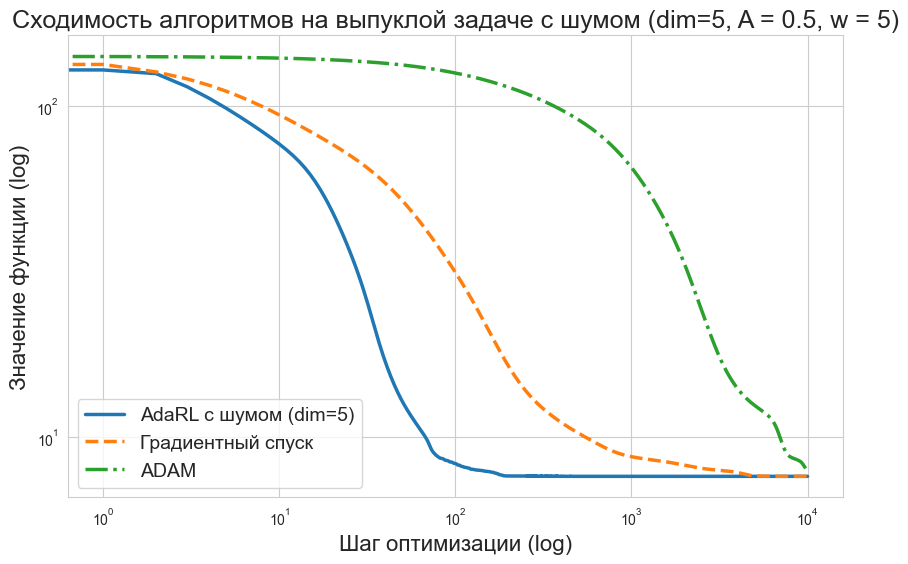

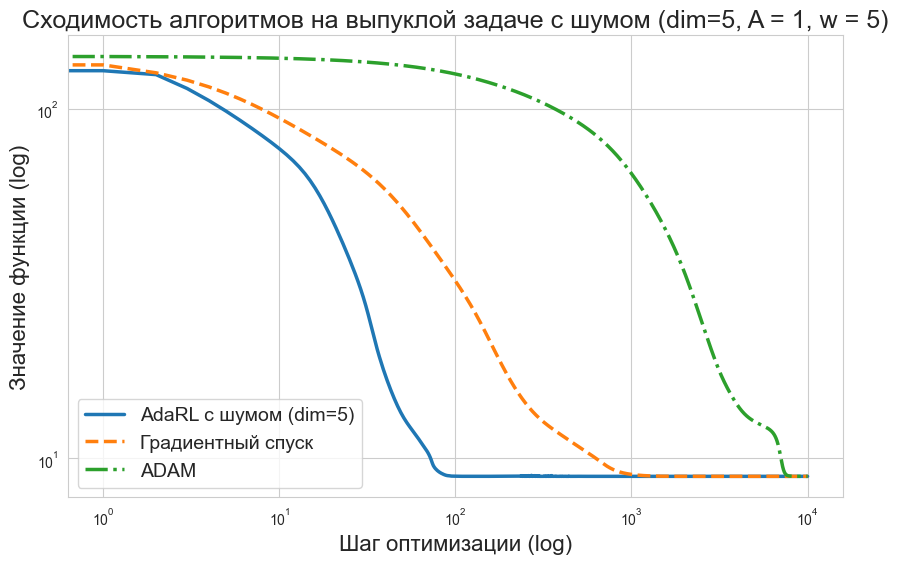

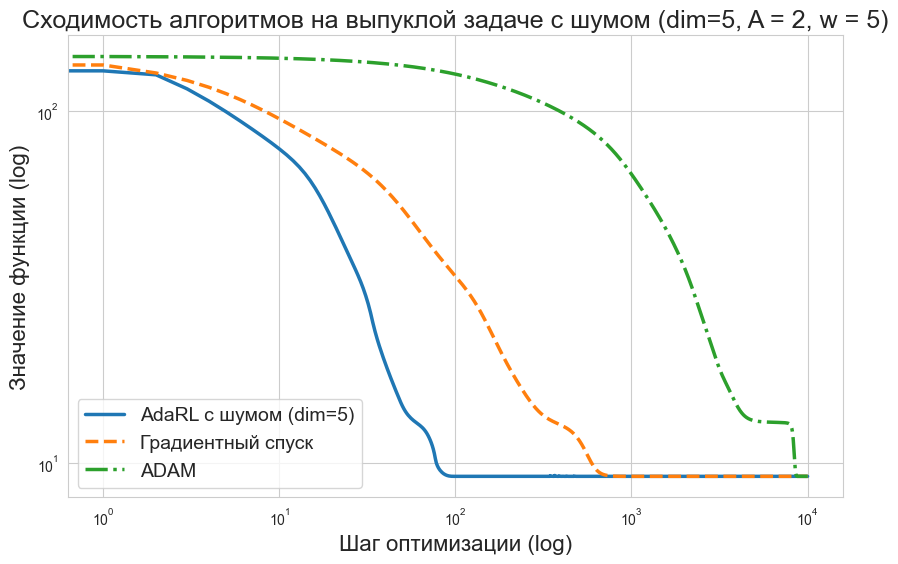

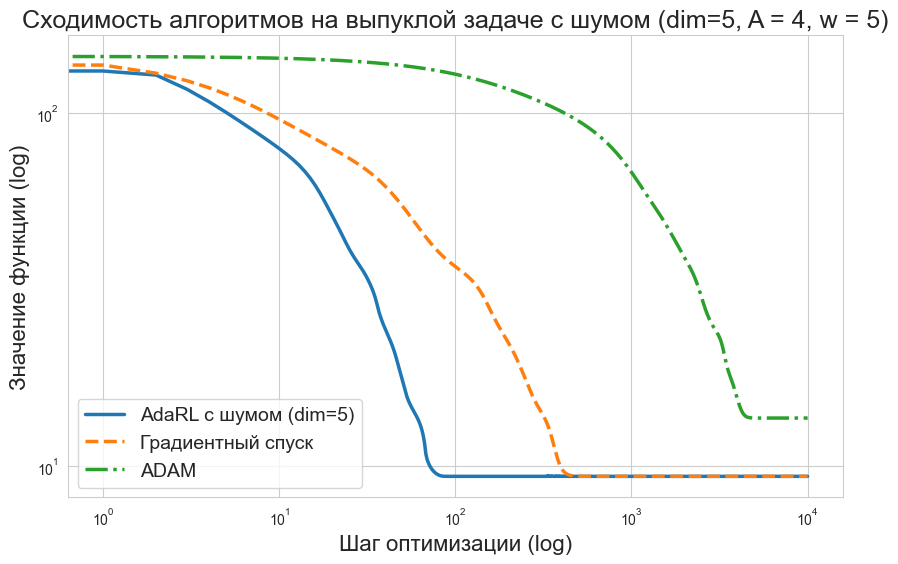

In [5]:
_frequency = 5
_amplitude = [0.5, 1, 2, 4]
dim = 5

for amplitude in _amplitude:
    base_env_kwargs = {
        "add_noise" : True,
        "amplitude" : amplitude,
        "frequency" : _frequency
    }

    stats = f"../models/noise_{dim}d_convex_vec_normalize.pkl"
    model = f"../models/noise_{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL с шумом (dim={dim})", env_config=env_config, model_dir=model_dir)

    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config, add_noise=True)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config, add_noise=True)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов на выпуклой задаче с шумом (dim=5, A = {amplitude}, w = {_frequency})")
    

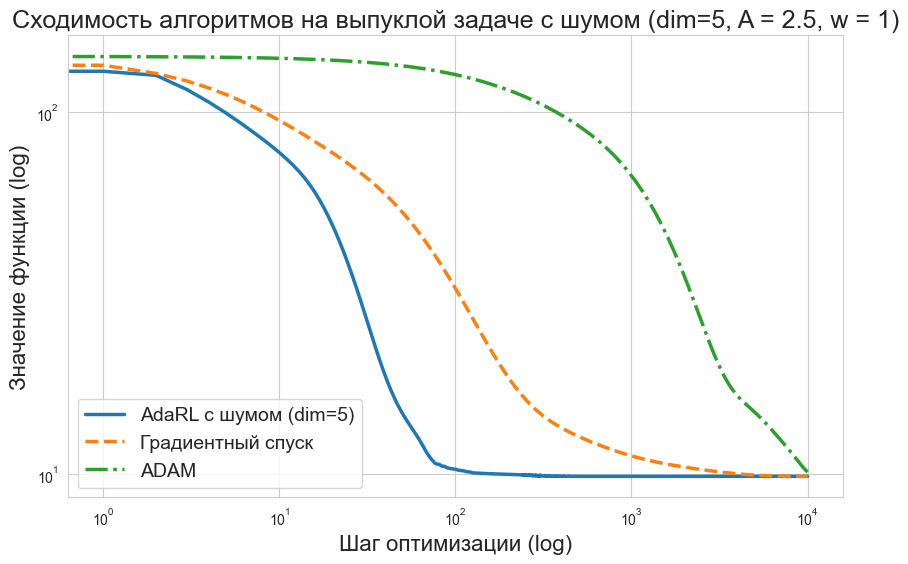

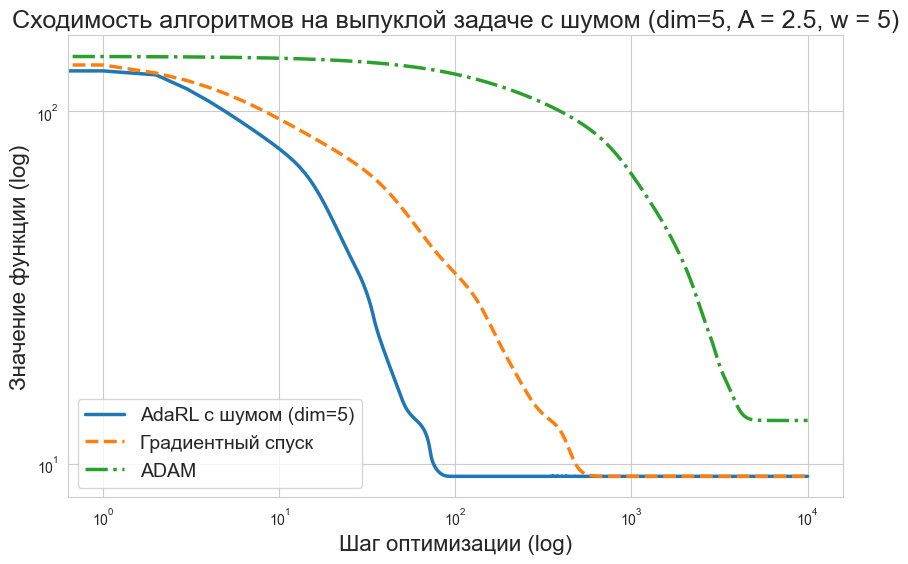

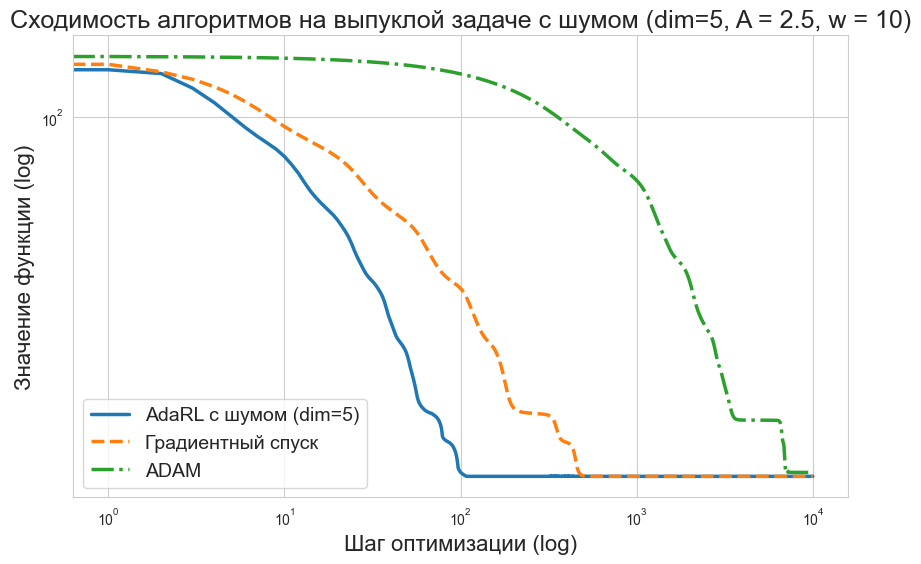

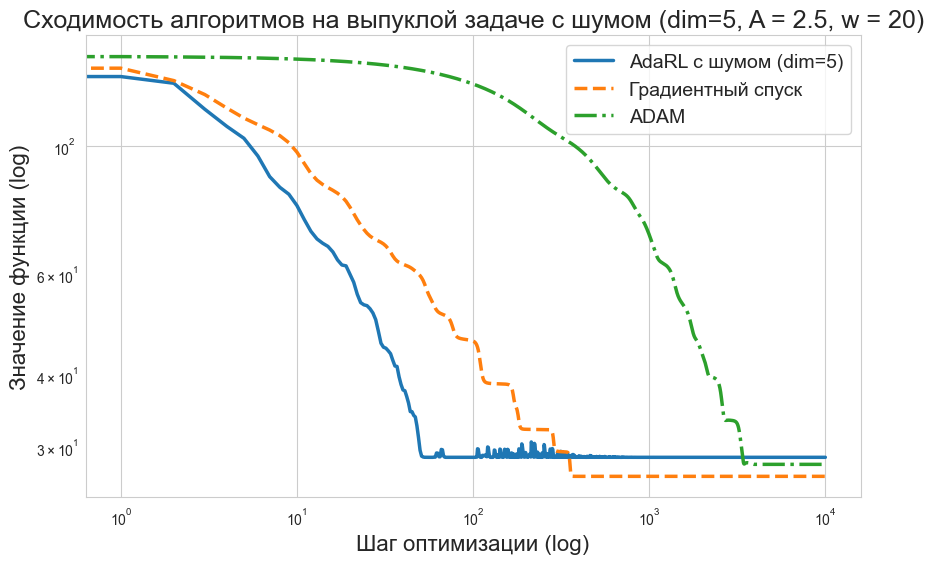

In [6]:
_amplitude = 2.5
_frequency = [1, 5, 10, 20]
dim = 5

for frequency in _frequency:
    base_env_kwargs = {
        "add_noise" : True,
        "amplitude" : _amplitude,
        "frequency" : frequency
    }

    stats = f"../models/noise_{dim}d_convex_vec_normalize.pkl"
    model = f"../models/noise_{dim}d_convex"
    
    env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)
    model_dir = exps.get_model_dir(stats, model)

    result_rl, x0, function = exps.optimize_exp_rl(method=f"AdaRL с шумом (dim={dim})", env_config=env_config, model_dir=model_dir)

    result_gdesc = exps.optimize_exp_standart(method="GD", x0=x0, function=function, env_config=env_config, add_noise=True)
    result_adam = exps.optimize_exp_standart(method="ADAM", x0=x0, function=function, env_config=env_config, add_noise=True)
    
    result = result_rl | result_gdesc | result_adam

    exps.plot_converging_comparasion(result, dim, title=f"Сходимость алгоритмов на выпуклой задаче с шумом (dim=5, A = {_amplitude}, w = {frequency})")
    

In [2]:
from tqdm import tqdm

_amplitudes = [0.5, 1, 2, 4]
_frequencies = [1, 5, 10, 20]
dim = 5
sample_count = 25

stats_path = f"../models/noise_{dim}d_convex_vec_normalize.pkl"
model_path = f"../models/noise_{dim}d_convex"
model_dir = exps.get_model_dir(stats_path, model_path)   


table = pd.DataFrame(index=_frequencies, columns=_amplitudes, dtype=object)
table.index.name = "w"
table.columns.name = "A"

for amplitude in tqdm(_amplitudes, desc="Amplitudes"):
    for frequency in _frequencies:
        print(f"\nProcessing A={amplitude}, w={frequency}")

        base_env_kwargs = {
            "add_noise": True,
            "amplitude": amplitude,
            "frequency": frequency
        }

        env_config = exps.get_env_config(seed, dim, max_iterations, env_id, env_kwargs=base_env_kwargs)

        rates = exps.compute_best_method_rates_batched(
            sample_count=sample_count,
            env_config=env_config,
            model_dir=model_dir   # используем предзагруженный model_dir
        )

        table.loc[frequency, amplitude] = f"{rates['AdaRL']:.0f} / {rates['GD']:.0f} / {rates['ADAM']:.0f}"

table

Amplitudes:   0%|          | 0/4 [00:00<?, ?it/s]


Processing A=0.5, w=1

Processing A=0.5, w=5

Processing A=0.5, w=10

Processing A=0.5, w=20


Amplitudes:  25%|██▌       | 1/4 [04:48<14:26, 288.70s/it]


Processing A=1, w=1

Processing A=1, w=5

Processing A=1, w=10

Processing A=1, w=20


Amplitudes:  50%|█████     | 2/4 [09:36<09:36, 288.46s/it]


Processing A=2, w=1

Processing A=2, w=5

Processing A=2, w=10

Processing A=2, w=20


Amplitudes:  75%|███████▌  | 3/4 [14:28<04:49, 289.86s/it]


Processing A=4, w=1

Processing A=4, w=5

Processing A=4, w=10

Processing A=4, w=20


Amplitudes: 100%|██████████| 4/4 [19:24<00:00, 291.16s/it]


A,0.5,1.0,2.0,4.0
w,,,,
1,88 / 20 / 16,88 / 24 / 16,96 / 24 / 16,84 / 60 / 20
5,80 / 44 / 16,76 / 56 / 16,48 / 56 / 28,44 / 52 / 36
10,68 / 52 / 16,68 / 36 / 20,48 / 40 / 36,56 / 32 / 28
20,52 / 28 / 20,48 / 20 / 36,40 / 48 / 24,36 / 28 / 48
